In [3]:
import numpy as np
import simulate_data as sim 
from gwas import gwas_linear, gwas_probit

n, d = 1000, 200
k = 10
corr = 0.7
rng=np.random.default_rng(42)
rho = 0.5
snr_s = 1
snr_y = 2
pi_s =0.1
pi_y = 0.05
p_sel = 0.5

X = sim.X_corr_blocks(n, d, k, corr, intercept=True, rng=rng)

data = sim.simulate_heckman(X, rho, snr_s, snr_y, pi_s, pi_y, p_sel, rng=rng)
s = data["s"]
y = data["y"]
beta_s = data["beta_s"]
beta_y = data["beta_y"]

b_s = gwas_probit(X, s)[0]
b_y = gwas_linear(X, y)[0]

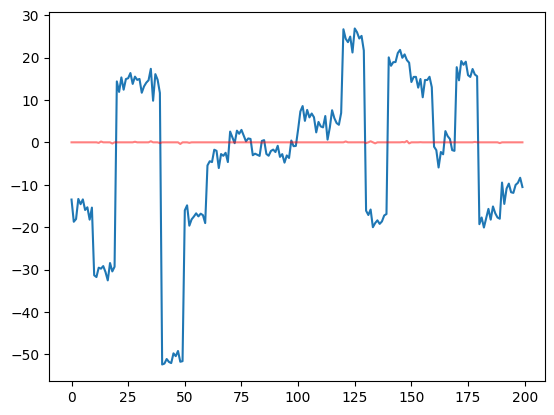

In [13]:
import matplotlib.pyplot as plt

R = np.corrcoef(X[:, 1:], rowvar=False)

plt.plot(R @ b_s[1:])     
plt.plot(beta_s[1:], color="red", alpha=0.5)  

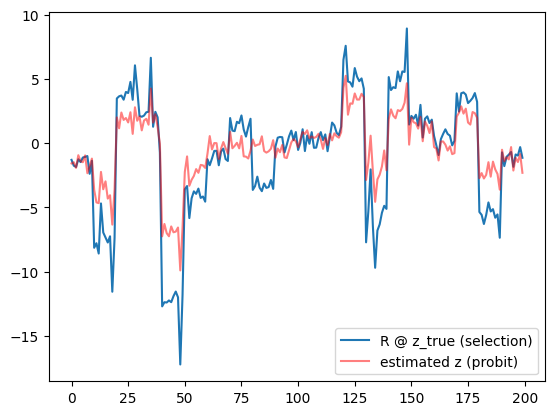

In [14]:
def true_beta_to_z_linear(beta_true, n, sigma_y):
    """
    Converts true marginal betas into expected z-scores for gwas_linear,
    assuming standardized X (column variance = 1).
    """
    se = sigma_y / np.sqrt(n)
    return beta_true / se


def true_beta_to_z_probit(beta_true, n, sigma_s):
    """
    Converts true marginal betas (on the latent scale) into expected
    z-scores for gwas_probit, assuming standardized X.
    """
    se = sigma_s / np.sqrt(n)
    return beta_true / se


sigma_y = data["sigma_y"]
sigma_s = data["sigma_s"]

z_true_y = true_beta_to_z_linear(beta_y[1:], n, sigma_y)
z_true_s = true_beta_to_z_probit(beta_s[1:], n, sigma_s)

R = np.corrcoef(X[:, 1:], rowvar=False)

plt.plot(R @ z_true_s, label="R @ z_true (selection)")
plt.plot(gwas_probit(X, s)[0][1:], color="red", alpha=0.5, label="estimated z (probit)")
plt.legend()